# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Zidan Alfariza Putra Pratama
- Email: zidanalfariza@gmail.com
- Id Dicoding: zidannnapp

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
# import library
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
import joblib
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

### Menyiapkan data yang akan digunakan

In [2]:
# dataset
data = pd.read_csv('dataset/employee_data.csv')

# informasi tentang dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

## Data Understanding

In [3]:
# melihat beberapa data awal
data.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


### Exploratory Data Analysis (EDA)

In [4]:
# Melihat distribusi data numerik
data.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


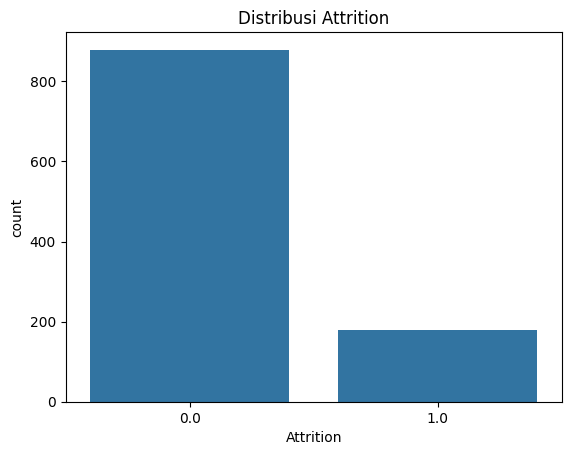

In [5]:
# Distribusi target variable
sns.countplot(x='Attrition', data=data)
plt.title('Distribusi Attrition')
plt.show()

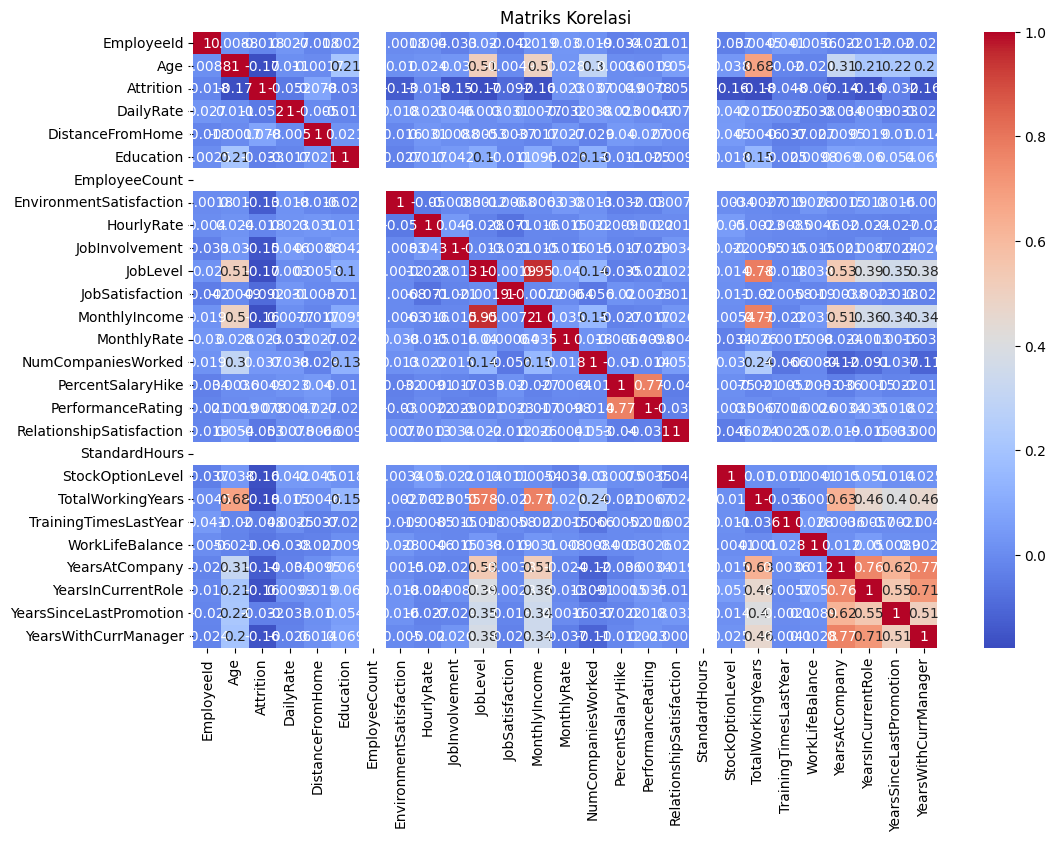

In [6]:
# Korelasi antar fitur numerik
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriks Korelasi')
plt.show()

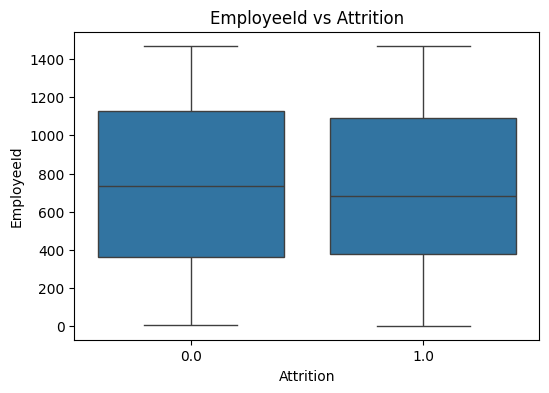

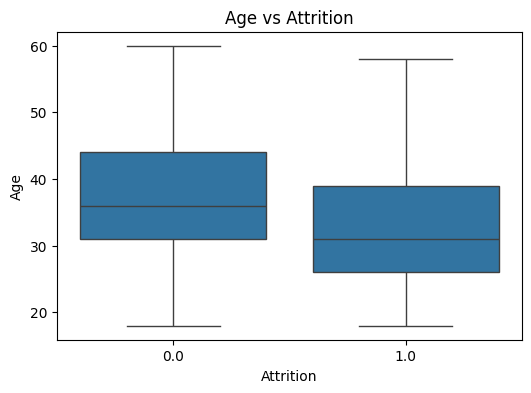

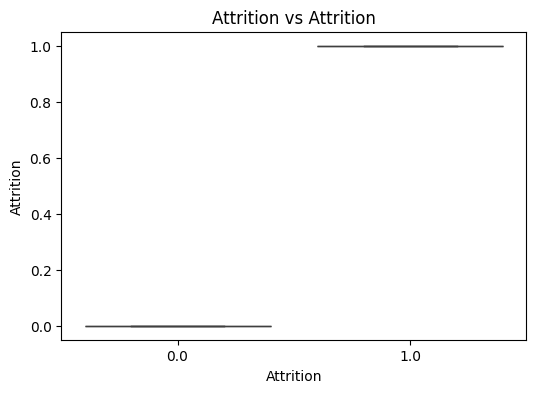

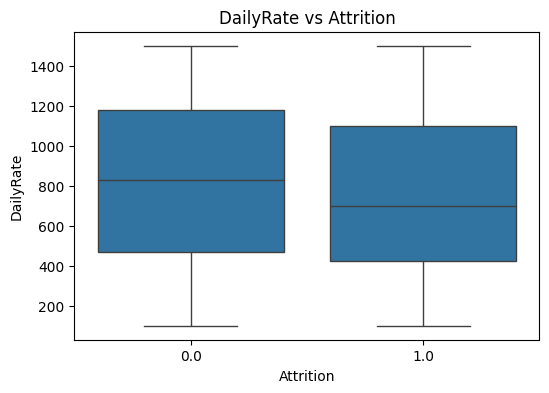

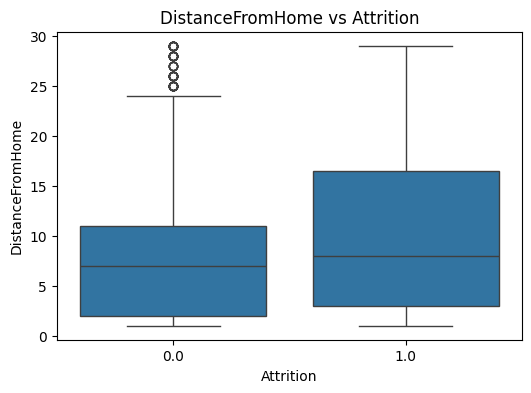

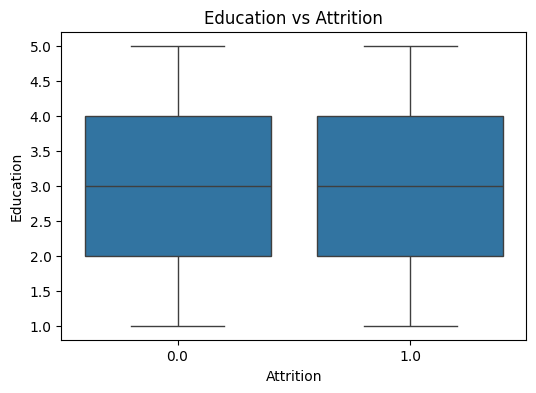

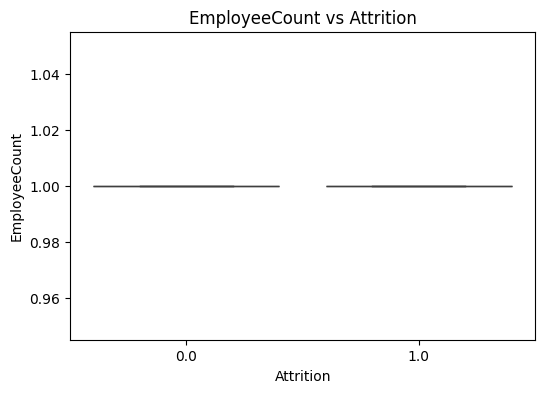

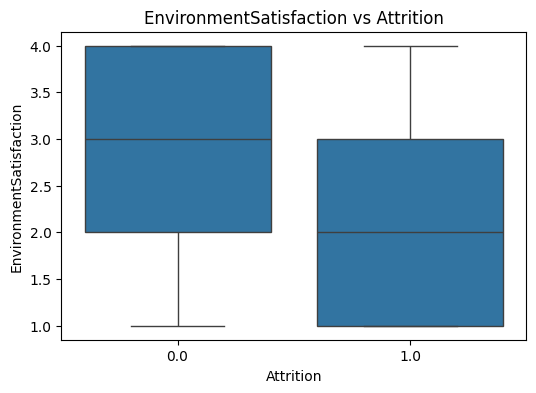

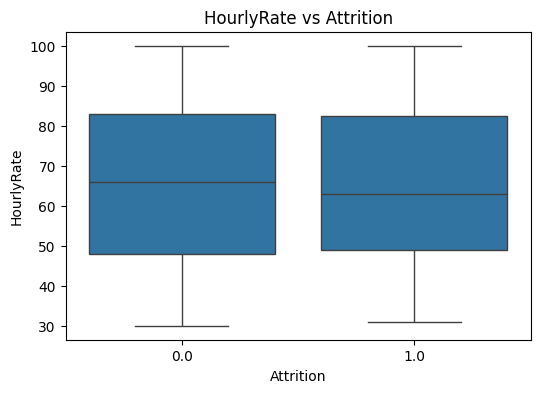

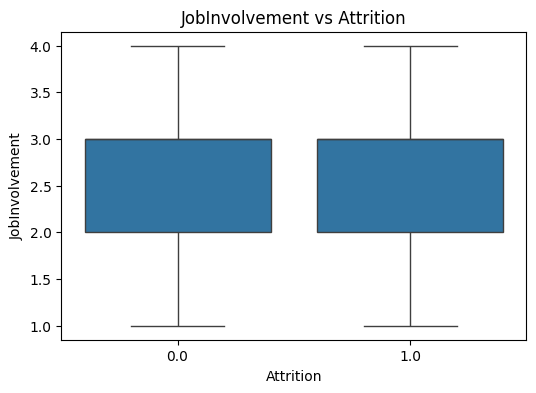

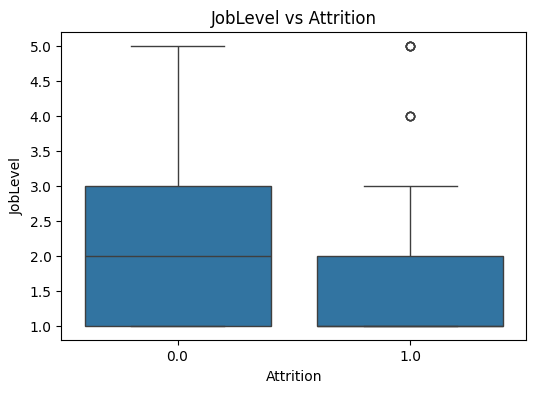

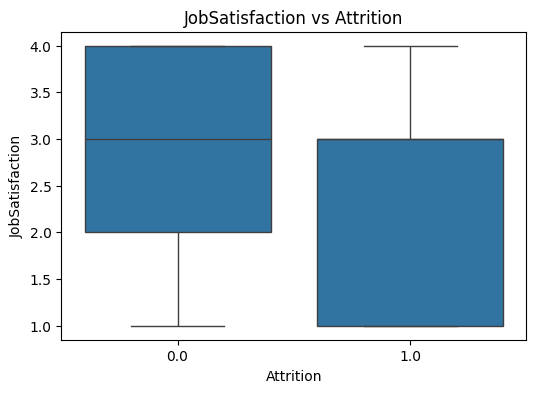

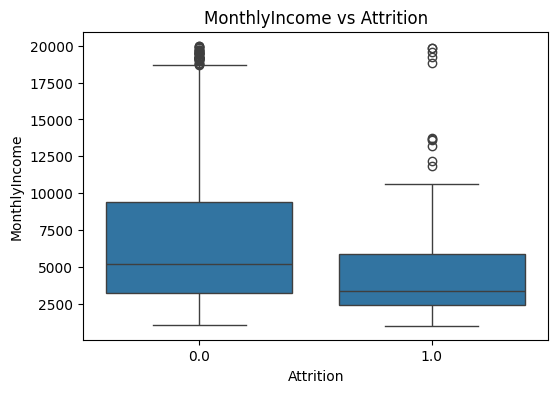

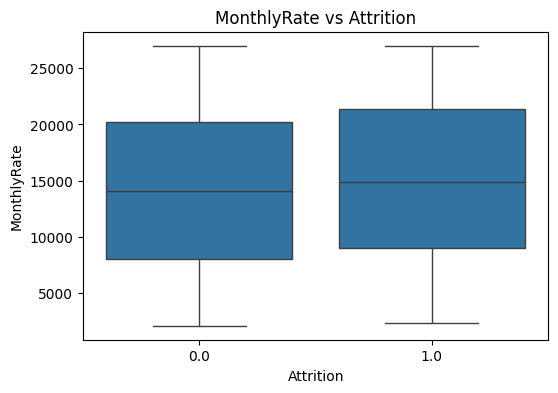

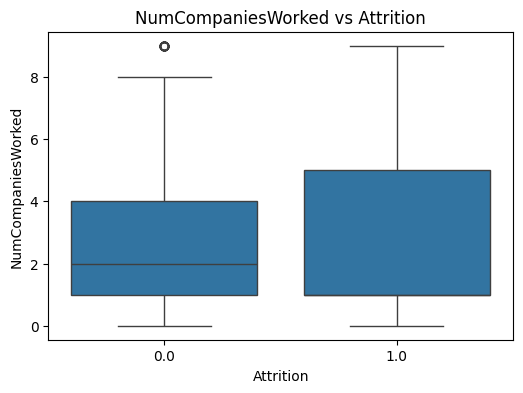

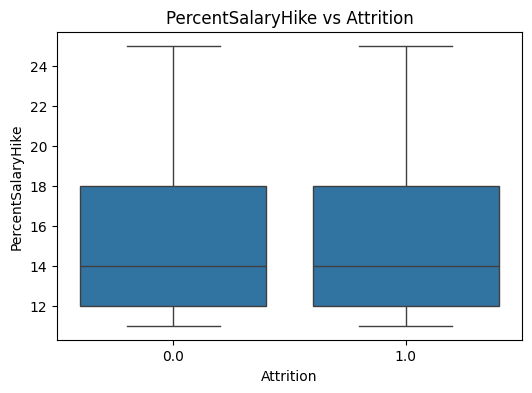

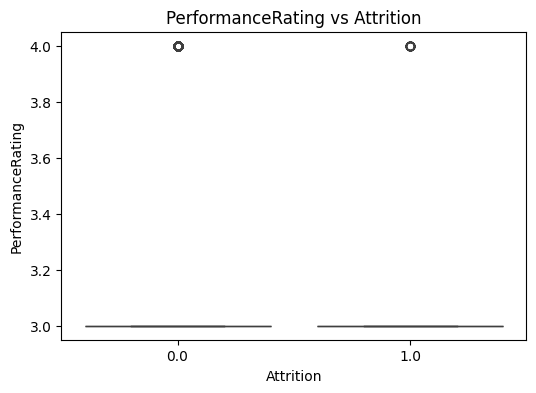

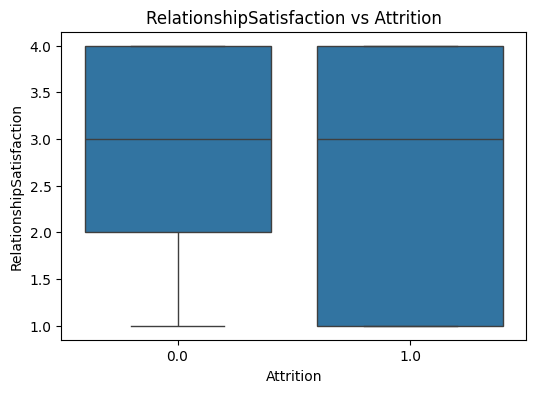

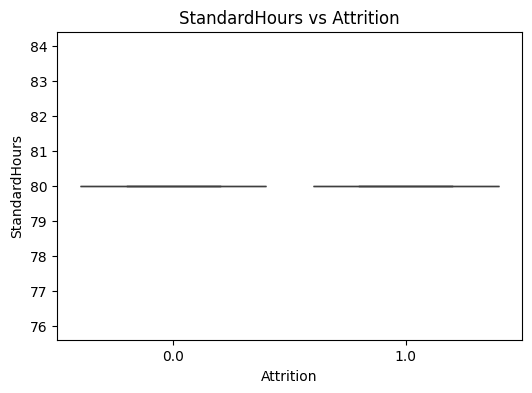

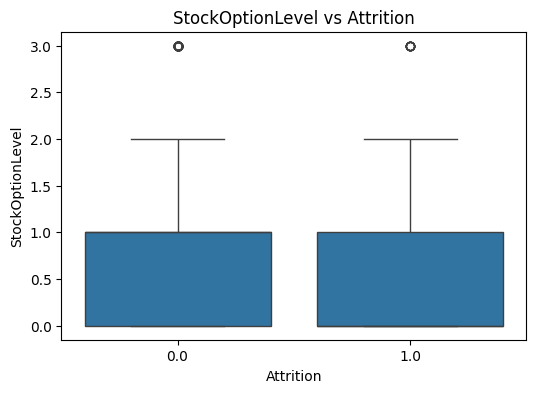

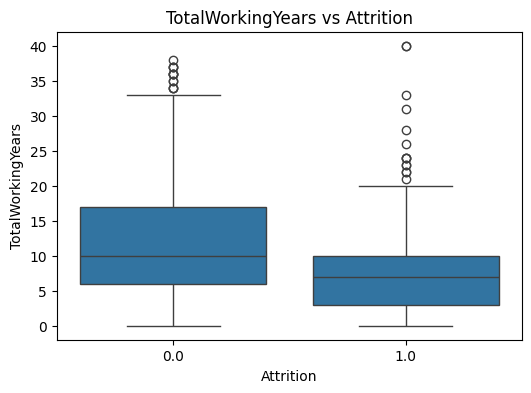

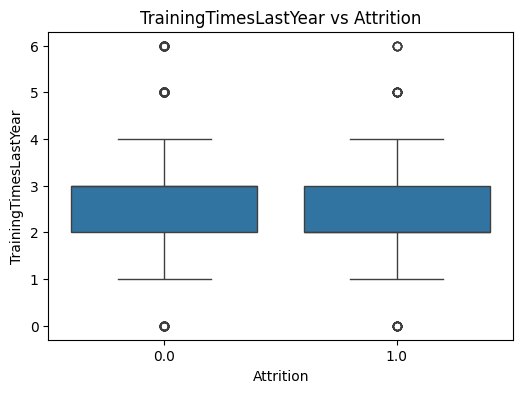

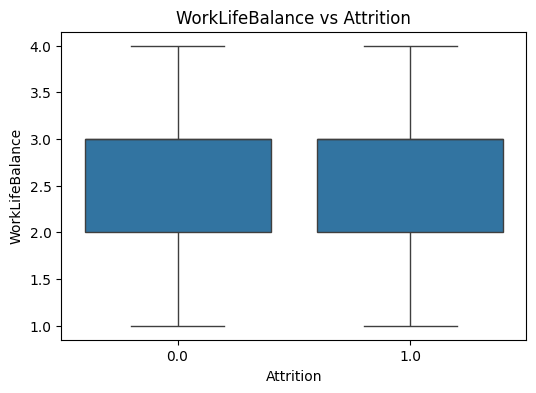

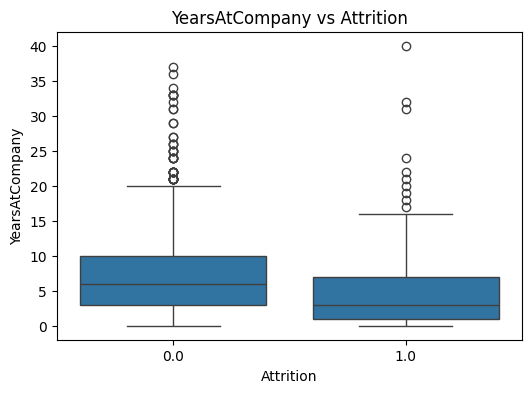

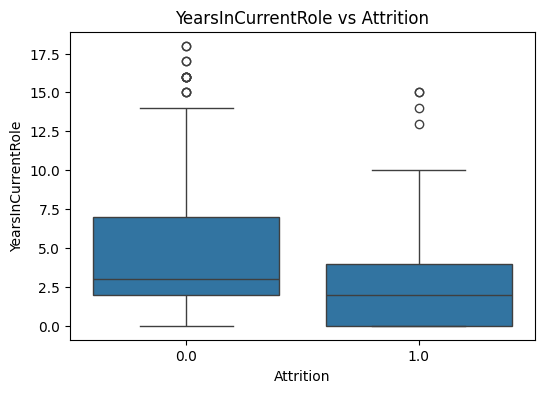

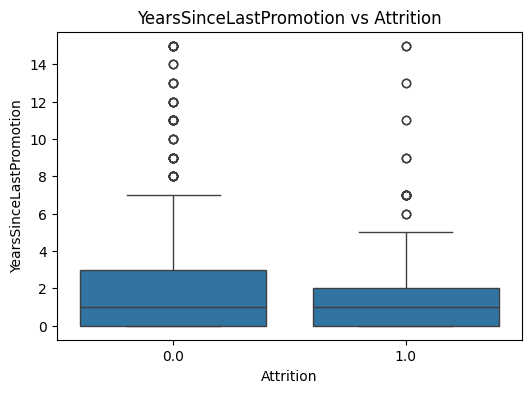

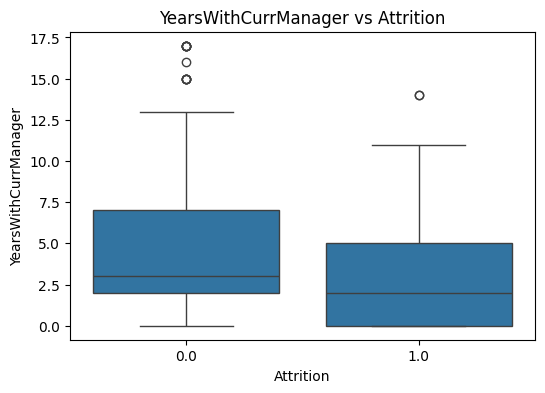

In [7]:
# Boxplot beberapa fitur numerik terhadap target
numerik_cols = data.select_dtypes(include=['int64', 'float64']).columns
for col in numerik_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Attrition', y=col, data=data)
    plt.title(f'{col} vs Attrition')
    plt.show()

## Data Preparation / Preprocessing

In [8]:
# salin DataFrame
data = data.copy()

# isi nilai yang hilang pada kolom 'Attrition' dengan modus (dari nilai terbanyak)
data['Attrition'] = data['Attrition'].fillna(data['Attrition'].mode()[0])

# pisahkan fitur dan target
X = data.drop('Attrition', axis=1)
y = data['Attrition']

# menangani data kategorikal dengan one-hot encoding
X = pd.get_dummies(X)

# normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# oversampling kelas minoritas dengan menggunakan SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# split data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# ukuran data setelah split
print(f"Ukuran data training: {X_train.shape}, Ukuran data testing: {X_test.shape}")

Ukuran data training: (2065, 55), Ukuran data testing: (517, 55)


## Modeling

In [9]:
# model menggunakan XGBoost
model = xgb.XGBClassifier(random_state=42, scale_pos_weight=10)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

## Evaluation

In [10]:
# prediksi dengan model
y_pred = model.predict(X_test)

# evaluasi model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Akurasi Model: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

# menyimpan model yang telah dilatih
joblib.dump(model, 'model/xgboost_model.pkl')


Akurasi Model: 0.9381044487427466
Confusion Matrix:
[[250  15]
 [ 17 235]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94       265
         1.0       0.94      0.93      0.94       252

    accuracy                           0.94       517
   macro avg       0.94      0.94      0.94       517
weighted avg       0.94      0.94      0.94       517



['model/xgboost_model.pkl']